# Malasanità in Italia — Preanalysis v2 (Euro-2013 proxy)
**Anno 2022 | Fonti: Ministero della Salute (A, C) + ISTAT (D)**

**Domanda:** Le regioni con meno personale sanitario hanno tassi di mortalità evitabile più alti?

Questa preanalysis usa il **Euro-2013 proxy**: 12 cause amenable/preventable dalla fonte D ISTAT.
Differenza rispetto a v1: la mortalità è filtrata per cause evitabili (non totale). Il risultato è un tasso grezzo 30+, non age-standardized.

*Cause incluse: Sepsi, Colon-retto, Polmone, Seno, Diabete, Ischemiche cuore, Cerebrovascolari, Ipertensive, Influenza/Polmonite, BPCO, Cirrosi, Cause esterne.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in [cwd, *cwd.parents]
     if (path / 'sources').exists() and (path / 'compose').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Non trovo la root di malasanita-struttura-mortalita')

repo_root = project_root.parents[2]
MART_PATH = repo_root / 'out' / 'data' / 'mart' / 'malasanita_a_strutture_asl' / '2022' / 'mart_compose_regioni.parquet'

df = pd.read_parquet(MART_PATH)
print(f'Regioni/PA caricate: {len(df)} | Anno: {df["anno"].iloc[0]}')
print(f'Join C ok: {df["join_c_ok"].sum()}/21 | Join D ok: {df["join_d_ok"].sum()}/21')
print(f'Colonna mortalita: decessi_evitabili_30plus_per_100k_pop_totale')

Regioni/PA caricate: 21 | Anno: 2022
Join C ok: 21/21 | Join D ok: 21/21
Colonna mortalita: decessi_evitabili_30plus_per_100k_pop_totale


> **Nota metodologica preliminare — leggere prima dei grafici**
>
> Questo notebook usa un **proxy Euro-2013** (12 cause amenable/preventable, fascia 30+).
> Il campo  ha un **denominatore ibrido**:
> numeratore = decessi 30+ sulle 12 cause; denominatore = popolazione totale regionale (non 30+).
> Non e’ un tasso grezzo canonico — e’ un indicatore proxy comparativo inter-regionale.
> Per confronti rigorosi serve age-standardizzazione esplicita (v3).
>
> Le correlazioni di Pearson restano positive anche con Euro-2013: il confondente demografico
> (regioni anziane = piu’ infrastruttura + piu’ mortalita’) non e’ rimosso dal filtro per cause.

## Panoramica regionale 2022

Tabella ordinata per mortalità evitabile decrescente.

In [2]:
cols_display = [
    'regione',
    'medici_mmg_per_100k',
    'infermieri_per_100k',
    'personale_osp_per_100k',
    'posti_letto_previsti_per_100k',
    'decessi_evitabili_30plus_per_100k_pop_totale',
]

tab = (
    df[cols_display]
    .sort_values('decessi_evitabili_30plus_per_100k_pop_totale', ascending=False)
    .reset_index(drop=True)
)
tab.columns = ['Regione', 'MMG/100k', 'Infermieri/100k', 'Pers.osp/100k', 'PL/100k', 'Evitabili30+/100k']
tab.index += 1
tab

,Regione,MMG/100k,Infermieri/100k,Pers.osp/100k,PL/100k,Evitabili30+/100k
1,LIGURIA,68.18,435.19,44.39,262.39,695.32
2,MOLISE,82.49,340.24,836.56,316.62,663.70
3,BASILICATA,78.35,185.89,172.40,141.36,619.77
4,PIEMONTE,65.50,272.56,180.79,279.39,607.42
5,UMBRIA,78.95,327.55,360.27,304.96,605.25
6,ABRUZZO,75.71,426.43,310.75,242.41,594.93
7,CALABRIA,71.14,283.11,381.09,188.42,587.67
8,FRIULI VENEZIA GIULIA,61.78,270.87,284.18,215.38,585.36
9,MARCHE,67.51,261.10,167.57,247.86,581.72
10,SICILIA,78.58,294.79,408.50,230.69,569.44


## Numeri chiave

In [3]:
mort = df['decessi_evitabili_30plus_per_100k_pop_totale']
mmg  = df['medici_mmg_per_100k']
inf  = df['infermieri_per_100k']

r_mort_max = df.loc[mort.idxmax(), 'regione']
r_mort_min = df.loc[mort.idxmin(), 'regione']
r_mmg_max  = df.loc[mmg.idxmax(),  'regione']
r_mmg_min  = df.loc[mmg.idxmin(),  'regione']

print("-- MORTALITA' EVITABILE 30+ per 100k (Euro-2013 proxy) --")
print(f'  Piu alta:  {r_mort_max:<30} {mort.max():.0f}')
print(f'  Piu bassa: {r_mort_min:<29} {mort.min():.0f}')
print(f'  Scarto max-min: {mort.max()-mort.min():.0f} decessi evitabili per 100k')
print(f'  Media nazionale: {mort.mean():.0f}')
print()
print('-- MMG per 100k --')
print(f'  Piu alto:  {r_mmg_max:<30} {mmg.max():.1f}')
print(f'  Piu basso: {r_mmg_min:<29} {mmg.min():.1f}')

-- MORTALITA' EVITABILE 30+ per 100k (Euro-2013 proxy) --
  Piu alta:  LIGURIA                        695
  Piu bassa: PROV. AUTON. BOLZANO          366
  Scarto max-min: 329 decessi evitabili per 100k
  Media nazionale: 549

-- MMG per 100k --
  Piu alto:  MOLISE                         82.5
  Piu basso: PROV. AUTON. BOLZANO          54.1


## Scatter — MMG vs mortalità evitabile 30+ (Euro-2013)

Asse X: MMG per 100k residenti (fonte A) | Asse Y: decessi evitabili 30+ per 100k (Euro-2013 proxy)

**Atteso:** correlazione negativa — più MMG, meno mortalità evitabile.

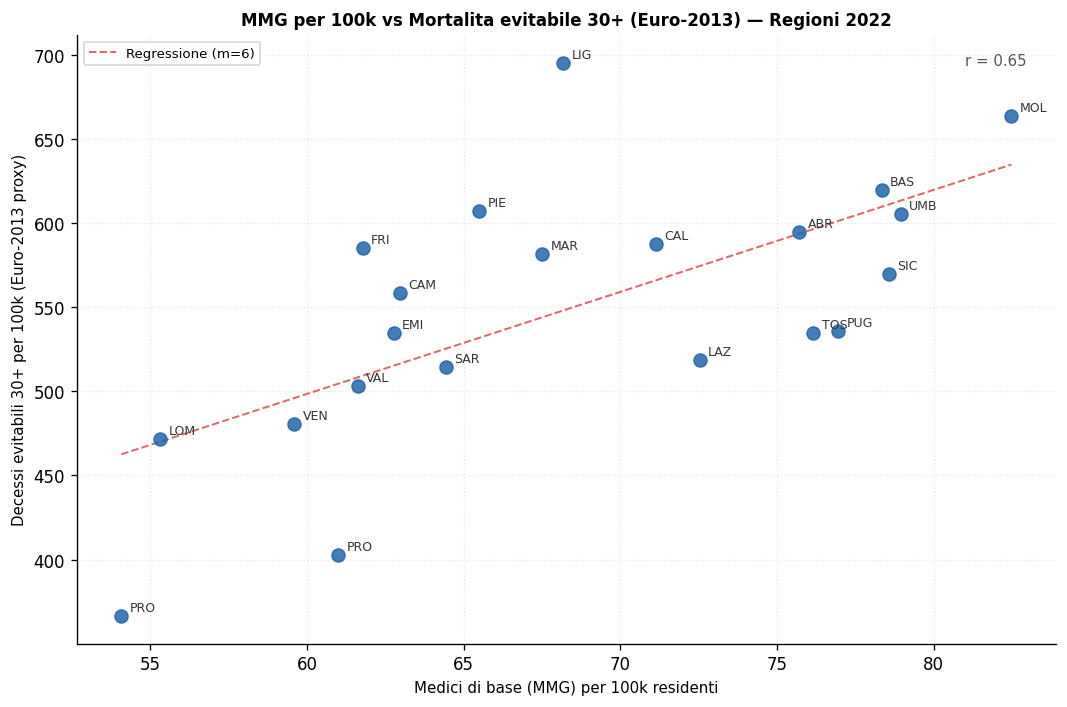

In [4]:
def sigla(nome):
    m = {
        'Valle': 'VDA', 'Bolzano': 'BZ', 'Trento': 'TN',
        'Friuli': 'FVG', 'Emilia': 'ER', 'Toscana': 'TOS',
        'Umbria': 'UMB', 'Liguria': 'LIG', 'Lombardia': 'LOM',
        'Piemonte': 'PIE', 'Veneto': 'VEN', 'Marche': 'MAR',
        'Lazio': 'LAZ', 'Abruzzo': 'ABR', 'Molise': 'MOL',
        'Campania': 'CAM', 'Puglia': 'PUG', 'Basilicata': 'BAS',
        'Calabria': 'CAL', 'Sicilia': 'SIC', 'Sardegna': 'SAR',
    }
    for k, v in m.items():
        if k in nome:
            return v
    return nome[:3].upper()


def scatter_plot(ax, x_col, y_col, x_label, title, df):
    x = df[x_col]
    y = df[y_col]
    ax.scatter(x, y, color='#2166ac', alpha=0.85, s=60, zorder=3)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='#d62728', linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'Regressione (m={m:.0f})')
    r = np.corrcoef(x, y)[0, 1]
    ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#555555')
    for _, row in df.iterrows():
        ax.annotate(sigla(row['regione']), (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5, color='#333333')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel('Decessi evitabili 30+ per 100k (Euro-2013 proxy)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle=':')


fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(ax, 'medici_mmg_per_100k', 'decessi_evitabili_30plus_per_100k_pop_totale',
             'Medici di base (MMG) per 100k residenti',
             'MMG per 100k vs Mortalita evitabile 30+ (Euro-2013) — Regioni 2022', df)
plt.tight_layout()
plt.show()

## Scatter — Infermieri vs mortalità evitabile 30+

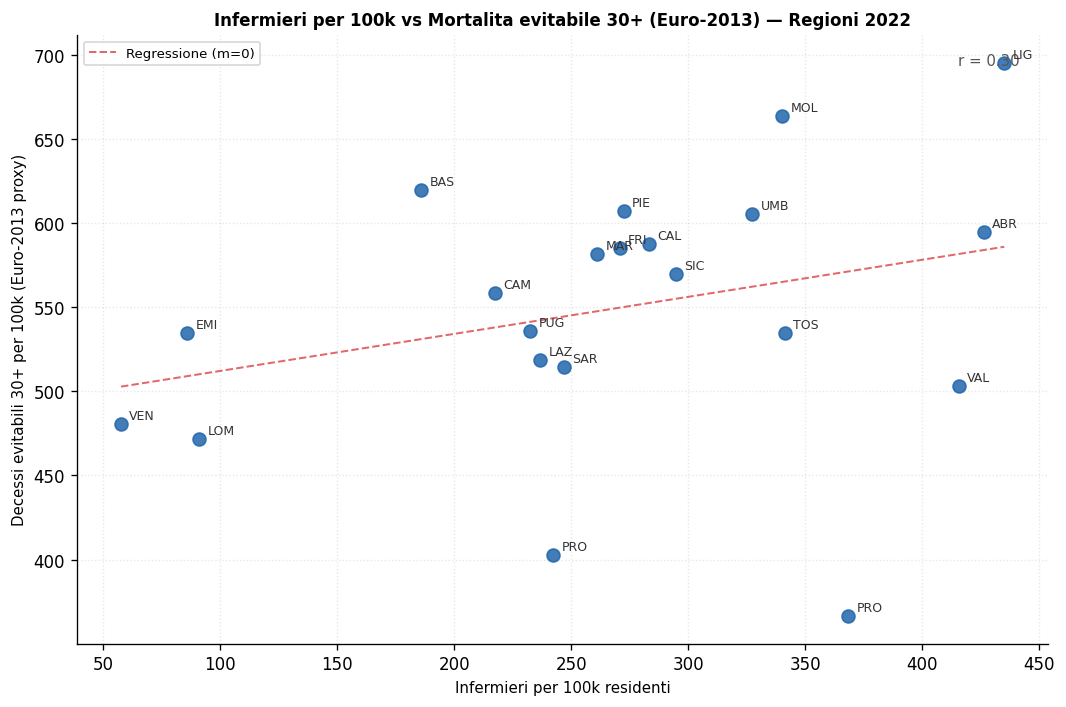

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(ax, 'infermieri_per_100k', 'decessi_evitabili_30plus_per_100k_pop_totale',
             'Infermieri per 100k residenti',
             'Infermieri per 100k vs Mortalita evitabile 30+ (Euro-2013) — Regioni 2022', df)
plt.tight_layout()
plt.show()

## Scatter — Personale ospedaliero vs mortalità evitabile 30+

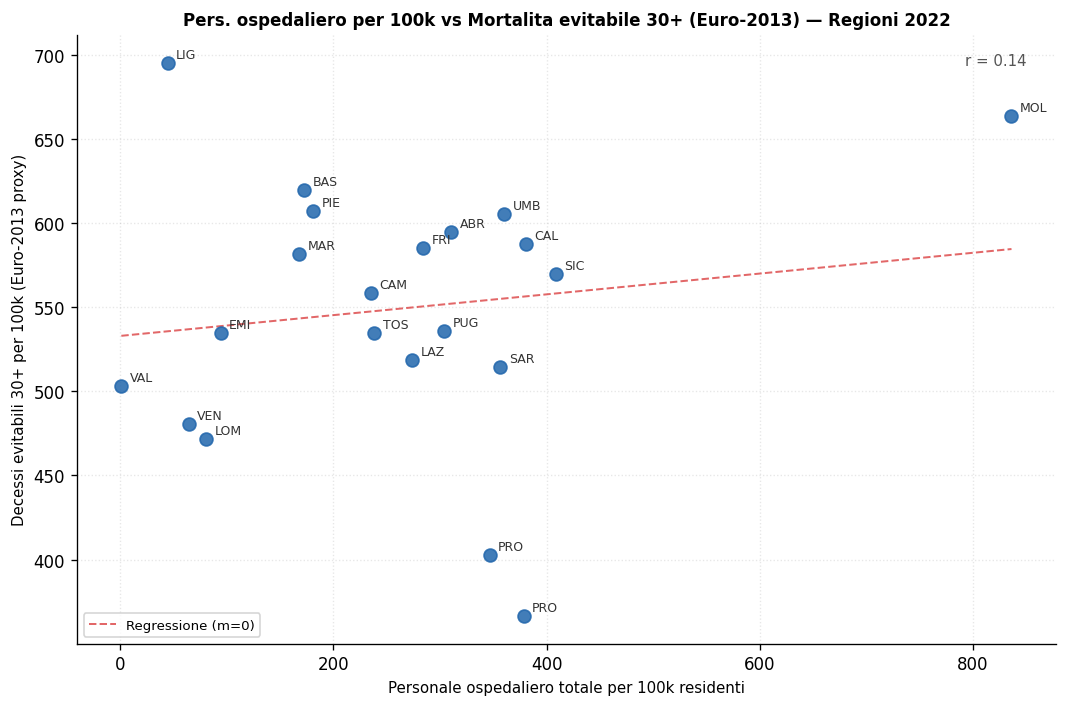

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(ax, 'personale_osp_per_100k', 'decessi_evitabili_30plus_per_100k_pop_totale',
             'Personale ospedaliero totale per 100k residenti',
             'Pers. ospedaliero per 100k vs Mortalita evitabile 30+ (Euro-2013) — Regioni 2022', df)
plt.tight_layout()
plt.show()

## Scatter — Posti letto vs mortalità evitabile 30+

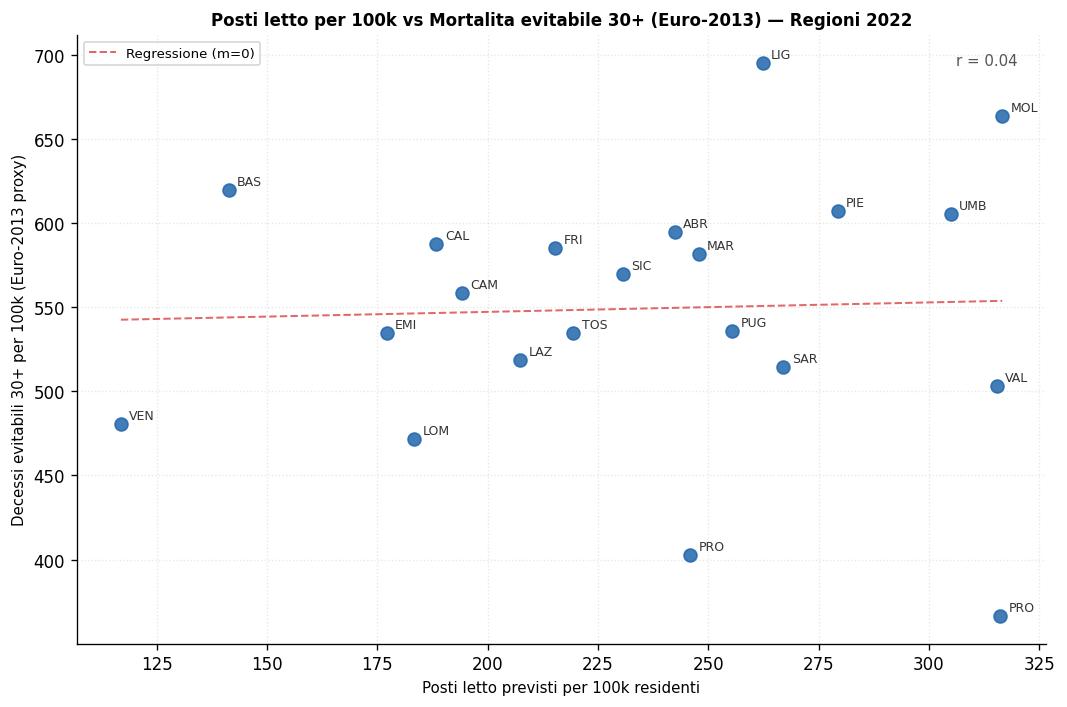

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(ax, 'posti_letto_previsti_per_100k', 'decessi_evitabili_30plus_per_100k_pop_totale',
             'Posti letto previsti per 100k residenti',
             'Posti letto per 100k vs Mortalita evitabile 30+ (Euro-2013) — Regioni 2022', df)
plt.tight_layout()
plt.show()

## Heatmap correlazioni Pearson

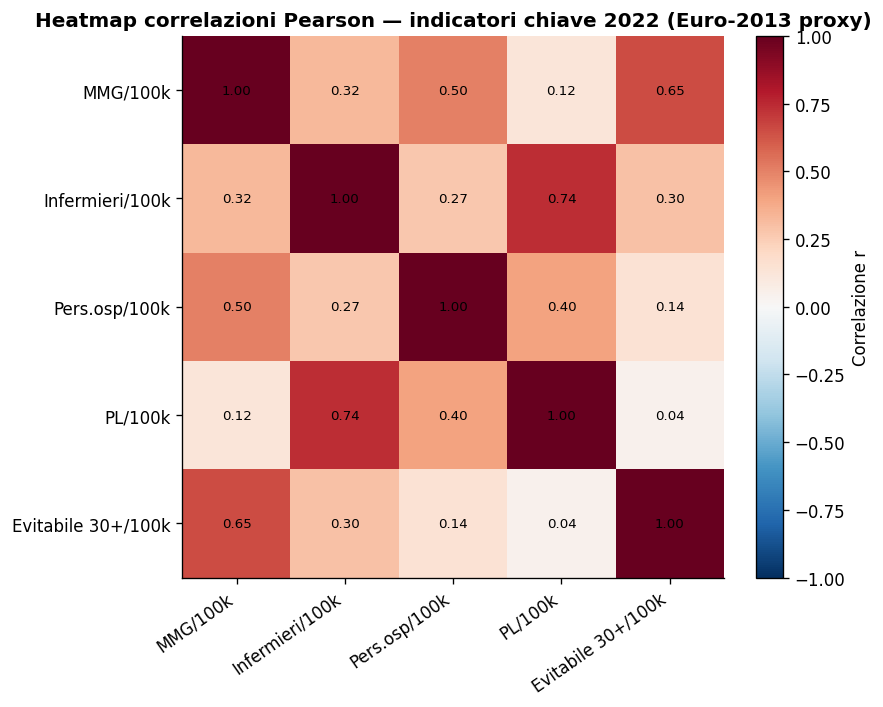

,medici_mmg_per_100k,infermieri_per_100k,personale_osp_per_100k,posti_letto_previsti_per_100k,decessi_evitabili_30plus_per_100k_pop_totale
medici_mmg_per_100k,1.000000,0.320926,0.500984,0.117708,0.648900
infermieri_per_100k,0.320926,1.000000,0.271606,0.739400,0.295640
personale_osp_per_100k,0.500984,0.271606,1.000000,0.404830,0.141996
posti_letto_previsti_per_100k,0.117708,0.739400,0.404830,1.000000,0.040226
decessi_evitabili_30plus_per_100k_pop_totale,0.648900,0.295640,0.141996,0.040226,1.000000


In [8]:
corr_cols = [
    'medici_mmg_per_100k',
    'infermieri_per_100k',
    'personale_osp_per_100k',
    'posti_letto_previsti_per_100k',
    'decessi_evitabili_30plus_per_100k_pop_totale',
]
corr = df[corr_cols].corr()

labels = ['MMG/100k', 'Infermieri/100k', 'Pers.osp/100k', 'PL/100k', 'Evitabile 30+/100k']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Heatmap correlazioni Pearson — indicatori chiave 2022 (Euro-2013 proxy)', fontweight='bold')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8, color='black')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlazione r')
plt.tight_layout()
plt.show()
corr

## Bar chart — Mortalità evitabile per regione e macro-area

Ordinato per mortalità decrescente. Colore = macro-area geografica.

Più immediato dello scatter per confrontare il posizionamento di ogni regione.

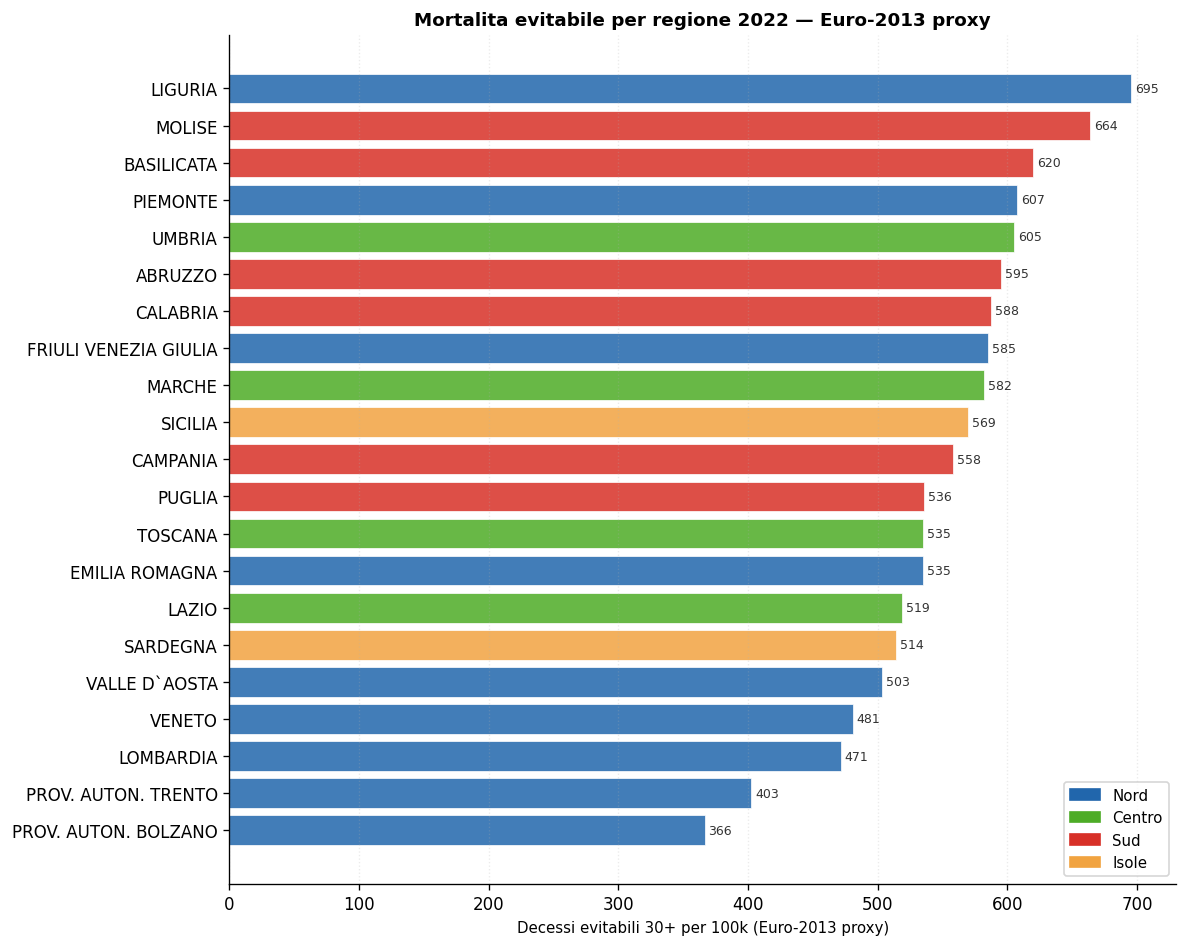

In [9]:
MACRO = {
    'PIEMONTE': 'Nord', 'VALLE D`AOSTA': 'Nord', 'LOMBARDIA': 'Nord',
    'PROV. AUTON. BOLZANO': 'Nord', 'PROV. AUTON. TRENTO': 'Nord',
    'VENETO': 'Nord', 'FRIULI VENEZIA GIULIA': 'Nord', 'LIGURIA': 'Nord',
    'EMILIA ROMAGNA': 'Nord',
    'TOSCANA': 'Centro', 'UMBRIA': 'Centro', 'MARCHE': 'Centro', 'LAZIO': 'Centro',
    'ABRUZZO': 'Sud', 'MOLISE': 'Sud', 'CAMPANIA': 'Sud', 'PUGLIA': 'Sud',
    'BASILICATA': 'Sud', 'CALABRIA': 'Sud',
    'SICILIA': 'Isole', 'SARDEGNA': 'Isole',
}
COLORS = {'Nord': '#2166ac', 'Centro': '#4dac26', 'Sud': '#d73027', 'Isole': '#f1a340'}

df_bar = df.copy()
df_bar['macro'] = df_bar['regione'].map(MACRO).fillna('Altro')
df_bar = df_bar.sort_values('decessi_evitabili_30plus_per_100k_pop_totale', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = df_bar['macro'].map(COLORS)
bars = ax.barh(df_bar['regione'], df_bar['decessi_evitabili_30plus_per_100k_pop_totale'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_bar['decessi_evitabili_30plus_per_100k_pop_totale']):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=7.5, color='#333333')

legend_handles = [mpatches.Patch(color=COLORS[m], label=m) for m in ['Nord', 'Centro', 'Sud', 'Isole']]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.set_xlabel('Decessi evitabili 30+ per 100k (Euro-2013 proxy)', fontsize=9)
ax.set_title('Mortalita evitabile per regione 2022 — Euro-2013 proxy', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

## Bubble chart — Personale ospedaliero vs mortalità evitabile

Dimensione bolla = popolazione residente. Colore = macro-area.

Permette di leggere il peso demografico di ogni regione: Lombardia e Campania occupano molto spazio, le PA (Bolzano, Trento) poco.

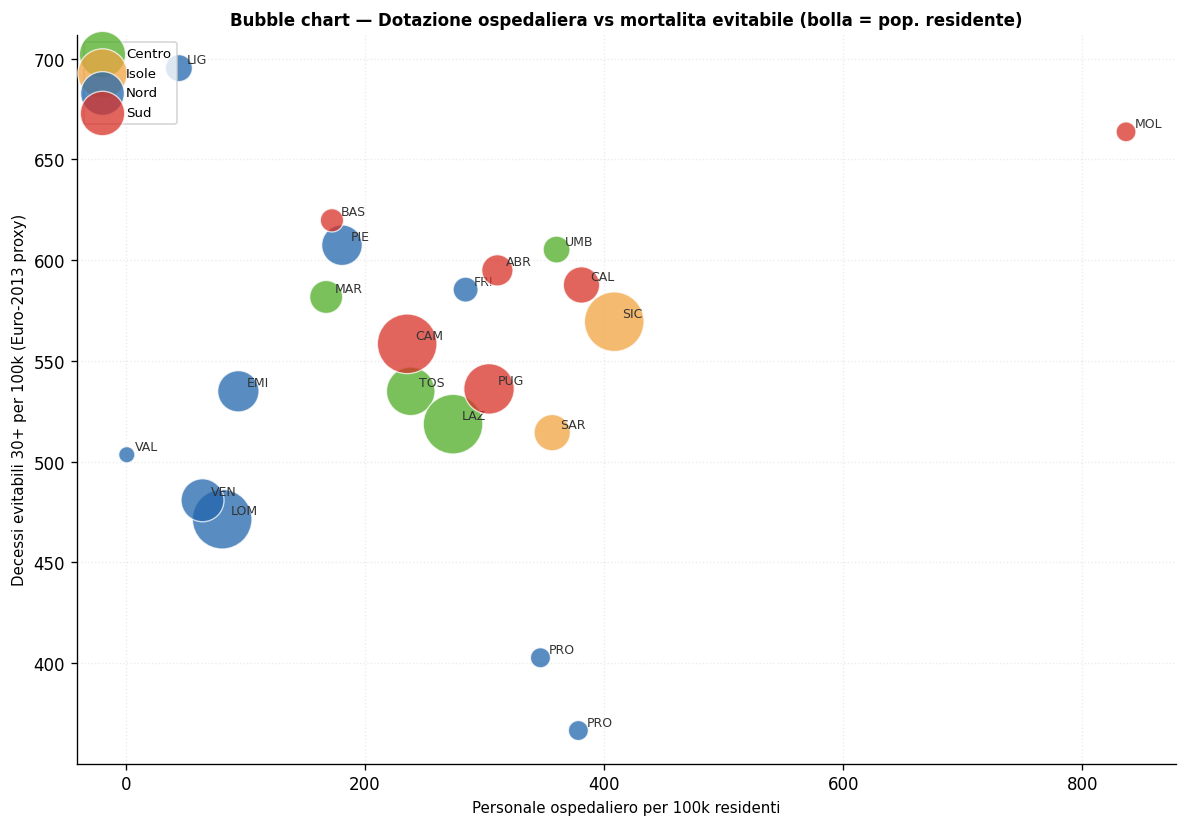

In [10]:
df_b = df.copy()
df_b['macro'] = df_b['regione'].map(MACRO).fillna('Altro')

fig, ax = plt.subplots(figsize=(10, 7))
for macro, g in df_b.groupby('macro'):
    size = g['pop_residente'] / g['pop_residente'].max() * 1200 + 80
    ax.scatter(g['personale_osp_per_100k'], g['decessi_evitabili_30plus_per_100k_pop_totale'],
               s=size, color=COLORS.get(macro, '#999'), alpha=0.75,
               edgecolors='white', linewidth=0.8, label=macro, zorder=3)
    for _, row in g.iterrows():
        ax.annotate(sigla(row['regione']),
                    (row['personale_osp_per_100k'], row['decessi_evitabili_30plus_per_100k_pop_totale']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5, color='#333333')

ax.set_xlabel('Personale ospedaliero per 100k residenti', fontsize=9)
ax.set_ylabel('Decessi evitabili 30+ per 100k (Euro-2013 proxy)', fontsize=9)
ax.set_title('Bubble chart — Dotazione ospedaliera vs mortalita evitabile (bolla = pop. residente)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

## Dumbbell — Ranking dotazione vs mortalità evitabile

Blu = rank personale ospedaliero (1 = più alto). Rosso = rank mortalità evitabile (1 = più alta).

Regioni dove le linee si incrociano molto = maggiore disallineamento tra dotazione e mortalità.

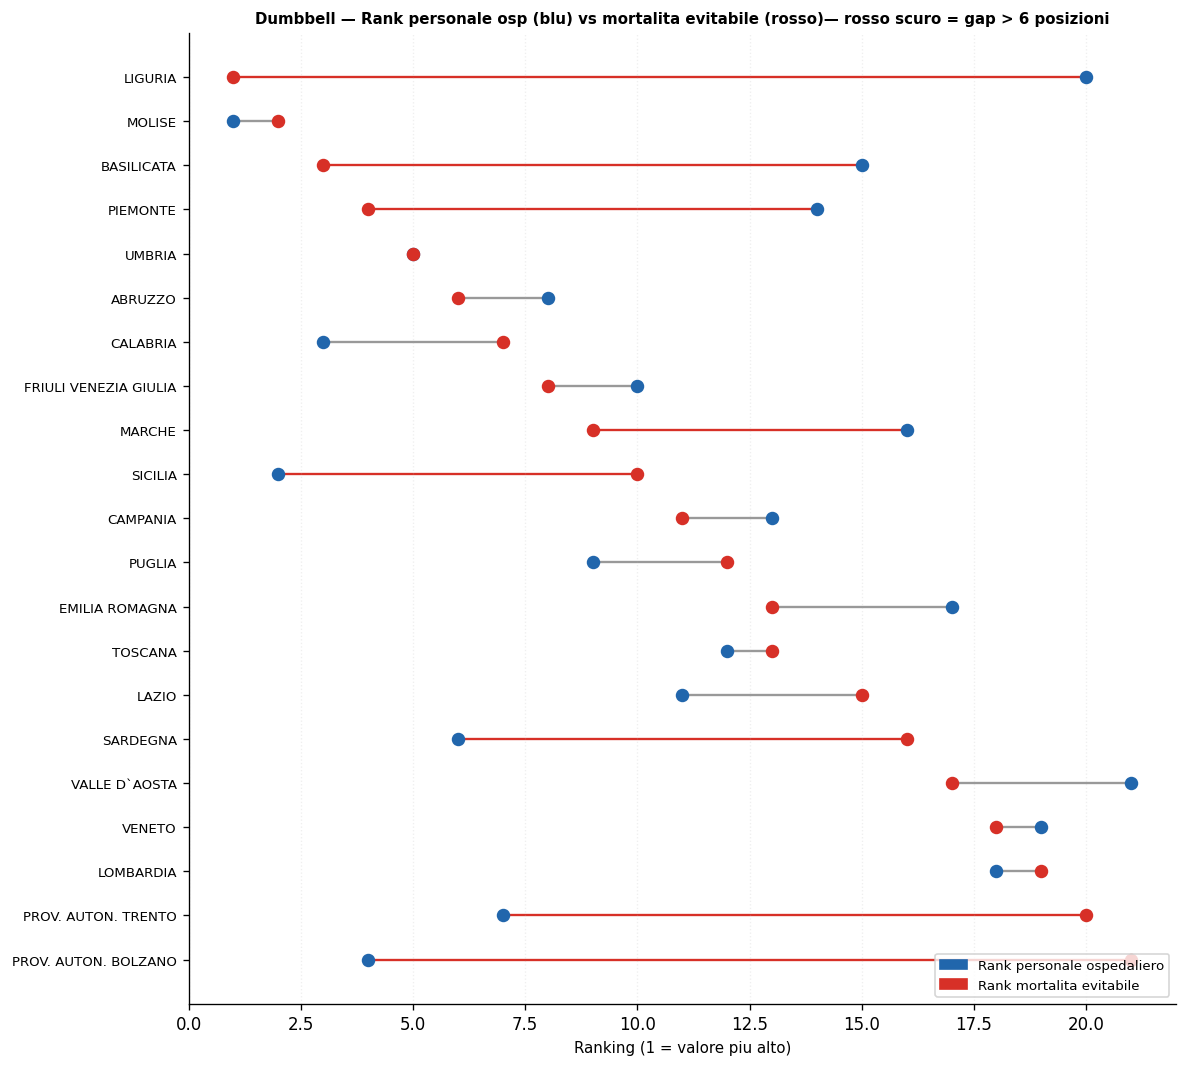

,regione,rank_personale,rank_mortalita,gap
0,LIGURIA,20.0,1.0,19
1,MOLISE,1.0,2.0,1
2,BASILICATA,15.0,3.0,12
3,PIEMONTE,14.0,4.0,10
4,UMBRIA,5.0,5.0,0
5,ABRUZZO,8.0,6.0,2
6,CALABRIA,3.0,7.0,4
7,FRIULI VENEZIA GIULIA,10.0,8.0,2
8,MARCHE,16.0,9.0,7
9,SICILIA,2.0,10.0,8


In [11]:
rank_df = df[['regione', 'personale_osp_per_100k', 'decessi_evitabili_30plus_per_100k_pop_totale']].copy()
rank_df['rank_personale'] = rank_df['personale_osp_per_100k'].rank(method='min', ascending=False)
rank_df['rank_mortalita'] = rank_df['decessi_evitabili_30plus_per_100k_pop_totale'].rank(method='min', ascending=False)
rank_df = rank_df.sort_values('rank_mortalita')

fig, ax = plt.subplots(figsize=(10, 9))
y_pos = np.arange(len(rank_df))
for i, (_, r) in enumerate(rank_df.iterrows()):
    color = '#d73027' if abs(r['rank_personale'] - r['rank_mortalita']) > 6 else '#999999'
    ax.plot([r['rank_personale'], r['rank_mortalita']], [i, i],
            color=color, linewidth=1.4, zorder=1)
    ax.scatter(r['rank_personale'], i, color='#2166ac', s=50, zorder=3)
    ax.scatter(r['rank_mortalita'], i, color='#d73027', s=50, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(rank_df['regione'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Ranking (1 = valore piu alto)', fontsize=9)
ax.set_title('Dumbbell — Rank personale osp (blu) vs mortalita evitabile (rosso)— rosso scuro = gap > 6 posizioni',
             fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.2, linestyle=':')
legend_handles = [
    mpatches.Patch(color='#2166ac', label='Rank personale ospedaliero'),
    mpatches.Patch(color='#d73027', label='Rank mortalita evitabile'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

rank_df[['regione', 'rank_personale', 'rank_mortalita']].assign(
    gap=lambda x: (x['rank_personale'] - x['rank_mortalita']).abs().astype(int)
).sort_values('rank_mortalita').reset_index(drop=True)

## Slope chart — Confronto ranking v1 (totale) vs v2 (Euro-2013)

Mostra quali regioni cambiano posizione nel ranking di mortalità quando si passa dal proxy totale (v1) al proxy evitabile Euro-2013 (v2).

Regioni che salgono con v2 = mortalità evitabile alta rispetto alla totale (potenziale segnale di performance sanitaria). Regioni che scendono = il contrario.

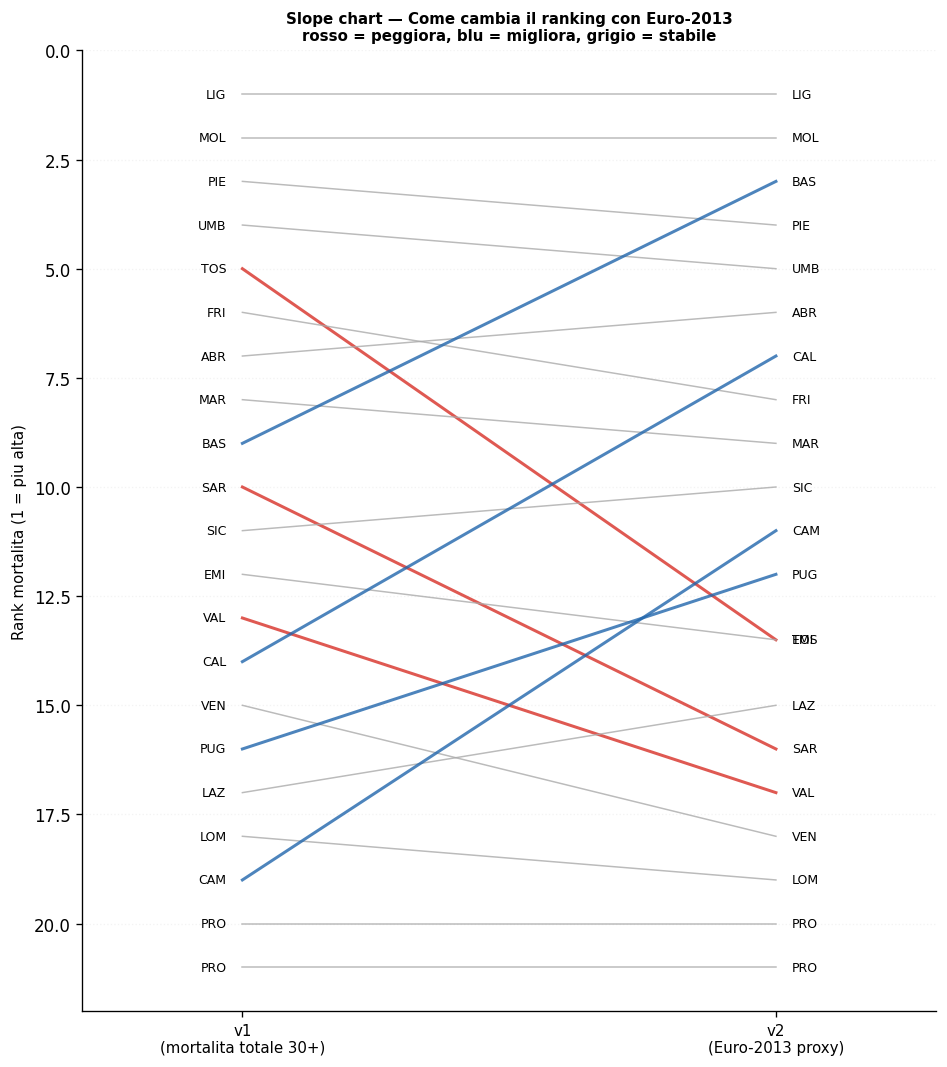

,regione,rank_v1,rank_v2,delta
0,CAMPANIA,19.0,11.0,-8
1,CALABRIA,14.0,7.0,-7
2,BASILICATA,9.0,3.0,-6
3,PUGLIA,16.0,12.0,-4
4,LAZIO,17.0,15.0,-2
5,ABRUZZO,7.0,6.0,-1
6,SICILIA,11.0,10.0,-1
7,LIGURIA,1.0,1.0,0
8,PROV. AUTON. BOLZANO,21.0,21.0,0
9,PROV. AUTON. TRENTO,20.0,20.0,0


In [12]:
import duckdb

# Calcola mortalita v1 (cod_causa=25, totale) direttamente dal clean parquet
clean_d_path = str(repo_root / 'out' / 'data' / 'clean' / 'malasanita_d_mortalita_istat' / '2022'
                   / 'malasanita_d_mortalita_istat_2022_clean.parquet')

v1_query = f"""
    SELECT territorio,
           decessi AS decessi_totali_v1,
           pop_media
    FROM read_parquet('{clean_d_path}')
    WHERE cod_sesso = 3 AND cod_classe_eta = 9
      AND cod_titolo_studio = 9 AND cod_causa = 25
"""
v1 = duckdb.query(v1_query).df()

# Merge con v2 tramite territorio_istat
slope = df[['regione', 'territorio_istat', 'decessi_evitabili_30plus_per_100k_pop_totale', 'pop_residente']].merge(
    v1, left_on='territorio_istat', right_on='territorio', how='left'
)
slope['mort_v1_per_100k'] = slope['decessi_totali_v1'] * 100000.0 / slope['pop_residente']
slope['rank_v1'] = slope['mort_v1_per_100k'].rank(ascending=False)
slope['rank_v2'] = slope['decessi_evitabili_30plus_per_100k_pop_totale'].rank(ascending=False)
slope = slope.sort_values('rank_v1')

fig, ax = plt.subplots(figsize=(8, 9))
for _, r in slope.iterrows():
    delta = r['rank_v2'] - r['rank_v1']
    color = '#d73027' if delta > 3 else ('#2166ac' if delta < -3 else '#aaaaaa')
    lw = 1.8 if abs(delta) > 3 else 0.9
    ax.plot([0, 1], [r['rank_v1'], r['rank_v2']], color=color, lw=lw, alpha=0.8)
    ax.text(-0.03, r['rank_v1'], sigla(r['regione']), ha='right', va='center', fontsize=7.5)
    ax.text(1.03, r['rank_v2'], sigla(r['regione']), ha='left', va='center', fontsize=7.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['v1\n(mortalita totale 30+)', 'v2\n(Euro-2013 proxy)'], fontsize=9)
ax.invert_yaxis()
ax.set_ylabel('Rank mortalita (1 = piu alta)', fontsize=9)
ax.set_title('Slope chart — Come cambia il ranking con Euro-2013\nrosso = peggiora, blu = migliora, grigio = stabile',
             fontsize=9, fontweight='bold')
ax.set_xlim(-0.3, 1.3)
ax.grid(axis='y', alpha=0.15, linestyle=':')
plt.tight_layout()
plt.show()

# Tabella variazioni significative
slope[['regione', 'rank_v1', 'rank_v2']].assign(
    delta=lambda x: (x['rank_v2'] - x['rank_v1']).astype(int)
).sort_values('delta').reset_index(drop=True)

## Risposta sintetica alla domanda analitica

Con Euro-2013 proxy (12 cause amenable/preventable, tasso grezzo 30+), le correlazioni di Pearson restano **tutte positive**:

| Indicatore | r con mortalita evitabile 30+ |
|---|---|
| MMG/100k | **+0.65** |
| Infermieri/100k | **+0.30** |
| Personale ospedaliero/100k | **+0.14** |
| Posti letto/100k | **+0.04** |

**La risposta con v2 è: ancora no, ma il quadro cambia rispetto a v1.**

### Cosa cambia rispetto a v1

- MMG sale da +0.52 a **+0.65** — il segnale si rafforza, non si attenua
- Personale ospedaliero sale da +0.04 a **+0.14** — ancora vicino al rumore con n=21
- Posti letto scende da +0.18 a **+0.04** — quasi nessuna relazione
- Infermieri scende da +0.39 a **+0.30**

### Perchè le correlazioni restano positive

Il confondente demografico non è rimosso dal filtro per cause evitabili: le regioni piu anziane (Liguria, Piemonte, FVG) hanno sia piu infrastruttura che piu mortalita evitabile, semplicemente perchè hanno piu popolazione anziana.
Per rimuovere il confondente serve **age-standardizzazione esplicita** (v3).

### Range nazionale 2022

- Piu alta: **Liguria 695/100k** | Piu bassa: **Bolzano 366/100k**
- Scarto: **329 decessi evitabili per 100k** tra la peggiore e la migliore
- Media nazionale: **549/100k**

### Outlier da verificare (segnalati da Gabrymi93 in PR #15)

- **Molise** e **Valle d'Aosta** mostrano valori anomali su  nella fonte C — possibile problema di copertura dato, non finding consolidato.

*Nota metodologica: Euro-2013 proxy su 12 cause amenable/preventable, tasso grezzo 30+ (non age-standardized). Denominatore = popolazione totale regionale da fonte A. Gap temporale dati Ministero fermi al 2022. Cause non mappabili (cervice, testicolo, tiroide): peso marginale sul totale evitabile.*